# Metadata preprocessing and exploration

This notebook loads, preprocesses, and explores the metadata associated with seismic signals (acceleration, velocity, or displacement). The data type is
configurable via the DATA_TYPE parameter. Metadata describe event and station characteristics including epicentral distance, peak ground motion, and site
classification. The analysis includes distribution plots, correlation analysis, and spatial visualization.

## 1. Imports and visualization settings

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from itertools import combinations
from scipy import stats
from IPython.display import display
from src import (build_metadata,
                 clean_metadata,
                 plot_column_types_pie,
                 plot_numerical_distributions,
                 plot_categorical_distributions,
                 plot_correlation_matrix,
                 plot_significant_corr_diff,
                 plot_station_map,
                 plot_pga_and_duration_by_component,
                 plot_pga_correlation_by_group,
                 set_plot_style,
                 corr_diff_to_latex,
                 metadata_table_to_latex,
                 constant_fields_to_latex)
import logging
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

Data type selection (acceleration, velocity, or displacement) and derivation of type-specific parameters: signal column name, physical unit, and peak column.
Output directories for figures, processed data, and LaTeX tables are also defined.

In [2]:
# EVENT_ID = 'INT-41004391'
EVENT_ID = 'IT-2009-0009'
DATA_TYPE = 'acceleration'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name and unit
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'acceleration'
    SIGNAL_UNIT = 'cm/s²'
    PEAK_COLUMN = 'PGA_CM/S^2'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'velocity'
    SIGNAL_UNIT = 'cm/s'
    PEAK_COLUMN = 'PGV_CM/S'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'displacement'
    SIGNAL_UNIT = 'cm'
    PEAK_COLUMN = 'PGD_CM'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

logger.info(f"Working with {DATA_TYPE} data")
logger.info(f"Signal column: {SIGNAL_COLUMN}")
logger.info(f"Peak column: {PEAK_COLUMN}")

INFO | Working with acceleration data
INFO | Signal column: acceleration
INFO | Peak column: PGA_CM/S^2


In [3]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Define all paths from project root
DATA_RAW = PROJECT_ROOT / 'data' / 'raw' / EVENT_ID
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01a_metadata' / DATA_TYPE
FIGURES_DIR = PROJECT_ROOT / 'figures' / EVENT_ID / '01a_metadata' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / 'latex_tables' / DATA_TYPE

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(DATA_PROCESSED.exists(), f"Processed data directory ready: {DATA_PROCESSED}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/acceleration
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/acceleration
INFO | Processed data directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01a_metadata/acceleration


## 3. Data loading

Raw metadata are extracted from the ITACA .ASC file headers within the corresponding zip archive.
The function `build_metadata` parses the header of each file and returns a dataframe with one row per recording.

In [4]:
# Load metadata
logger.info("Loading metadata...")

# Determine zip filename based on data type
if DATA_TYPE == 'acceleration':
    zip_filename = 'query_acc.zip'
elif DATA_TYPE == 'velocity':
    zip_filename = 'query_vel.zip'
elif DATA_TYPE == 'displacement':
    zip_filename = 'query_disp.zip'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

zip_path = DATA_RAW / zip_filename
df_meta = build_metadata(zip_path)

# Check if metadata was loaded successfully
check(df_meta is not None, "Metadata dataframe created")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata dataframe loaded, shape: {df_meta.shape}")

INFO | Loading metadata...
INFO | Metadata dataframe created
INFO | Metadata dataframe is not empty
INFO | Metadata dataframe loaded, shape: (192, 65)


## 4. Exploration (raw)

Preliminary inspection of the raw metadata: column types, missing values,
and sample records. This provides a baseline understanding before cleaning.

Export of the complete metadata table to LaTeX format.

In [13]:
output_path = LATEX_TABLES_DIR / f'header_table_{DATA_TYPE[:3]}.tex'
latex_table = metadata_table_to_latex(df_meta, output_path=output_path)

Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/displacement/header_table_dis.tex


Initial inspection of the raw metadata: shape, column names, data types distribution, and missing value count. The first five rows are displayed for reference.

In [14]:
# Preview dataset
logger.info("Previewing dataset")

# Shape
print("Metadata DataFrame shape:", df_meta.shape)

# Columns
print("\nMetadata columns:")
for col in df_meta.columns:
    print(f"  {col}")

# Data types
print("\nColumn types distribution:")
print(df_meta.dtypes.value_counts())

# Missing values
print("Missing values (NaN) in raw df_meta:")
print(df_meta.isnull().sum().sum())

# Display dataset head
display(df_meta.head())

INFO | Previewing dataset


Metadata DataFrame shape: (192, 65)

Metadata columns:
  file
  EVENT_NAME
  EVENT_ID
  EVENT_DATE_YYYYMMDD
  EVENT_TIME_HHMMSS
  EVENT_LATITUDE_DEGREE
  EVENT_LONGITUDE_DEGREE
  EVENT_DEPTH_KM
  HYPOCENTER_REFERENCE
  MAGNITUDE_W
  MAGNITUDE_W_REFERENCE
  MAGNITUDE_L
  MAGNITUDE_L_REFERENCE
  FOCAL_MECHANISM
  NETWORK
  STATION_CODE
  STATION_NAME
  STATION_LATITUDE_DEGREE
  STATION_LONGITUDE_DEGREE
  STATION_ELEVATION_M
  LOCATION
  SENSOR_DEPTH_M
  VS30_M/S
  SITE_CLASSIFICATION_EC8
  MORPHOLOGIC_CLASSIFICATION
  EPICENTRAL_DISTANCE_KM
  EARTHQUAKE_BACKAZIMUTH_DEGREE
  DATE_TIME_FIRST_SAMPLE_YYYYMMDD_HHMMSS
  DATE_TIME_FIRST_SAMPLE_PRECISION
  SAMPLING_INTERVAL_S
  NDATA
  DURATION_S
  STREAM
  UNITS
  INSTRUMENT
  INSTRUMENT_ANALOG/DIGITAL
  INSTRUMENTAL_FREQUENCY_HZ
  INSTRUMENTAL_DAMPING
  FULL_SCALE_G
  N_BIT_DIGITAL_CONVERTER
  PGD_CM
  TIME_PGD_S
  BASELINE_CORRECTION
  FILTER_TYPE
  FILTER_ORDER
  LOW_CUT_FREQUENCY_HZ
  HIGH_CUT_FREQUENCY_HZ
  LATE/NORMAL_TRIGGERED
  DATABASE

,file,EVENT_NAME,EVENT_ID,EVENT_DATE_YYYYMMDD,EVENT_TIME_HHMMSS,EVENT_LATITUDE_DEGREE,EVENT_LONGITUDE_DEGREE,EVENT_DEPTH_KM,HYPOCENTER_REFERENCE,MAGNITUDE_W,...,DATA_CREATOR,ORIGINAL_DATA_MEDIATOR_CITATION,ORIGINAL_DATA_MEDIATOR,ORIGINAL_DATA_CREATOR_CITATION,ORIGINAL_DATA_CREATOR,USER1,USER2,USER3,USER4,USER5
0,BA.SANL.00.HNE.D.IT-2009-0009.DIS.MP.ASC,None,IT-2009-0009,20090406,013240,42.3420,13.3800,8.3,INGV-CNT_Seismic_Bulletin,6.1,...,ITACA working group,"Basilicata Accelerometric Network, DOI 10.1007...","Ing. Maria Rosaria Gallipoli, CNR-IMAA, mariar...",http://www.fdsn.org/networks/detail/BA/,network: BA (UniBAS); owner: Universita della ...,,,,,
1,BA.SANL.00.HNN.D.IT-2009-0009.DIS.MP.ASC,None,IT-2009-0009,20090406,013240,42.3420,13.3800,8.3,INGV-CNT_Seismic_Bulletin,6.1,...,ITACA working group,"Basilicata Accelerometric Network, DOI 10.1007...","Ing. Maria Rosaria Gallipoli, CNR-IMAA, mariar...",http://www.fdsn.org/networks/detail/BA/,network: BA (UniBAS); owner: Universita della ...,,,,,
2,BA.SANL.00.HNZ.D.IT-2009-0009.DIS.MP.ASC,None,IT-2009-0009,20090406,013240,42.3420,13.3800,8.3,INGV-CNT_Seismic_Bulletin,6.1,...,ITACA working group,"Basilicata Accelerometric Network, DOI 10.1007...","Ing. Maria Rosaria Gallipoli, CNR-IMAA, mariar...",http://www.fdsn.org/networks/detail/BA/,network: BA (UniBAS); owner: Universita della ...,,,,,
3,BA.TTS.00.HNE.D.IT-2009-0009.DIS.MP.ASC,None,IT-2009-0009,20090406,013240,42.3420,13.3800,8.3,INGV-CNT_Seismic_Bulletin,6.1,...,ITACA working group,"Basilicata Accelerometric Network, DOI 10.1007...","Ing. Maria Rosaria Gallipoli, CNR-IMAA, mariar...",http://www.fdsn.org/networks/detail/BA/,network: BA (UniBAS); owner: Universita della ...,,,,,
4,BA.TTS.00.HNN.D.IT-2009-0009.DIS.MP.ASC,None,IT-2009-0009,20090406,013240,42.3420,13.3800,8.3,INGV-CNT_Seismic_Bulletin,6.1,...,ITACA working group,"Basilicata Accelerometric Network, DOI 10.1007...","Ing. Maria Rosaria Gallipoli, CNR-IMAA, mariar...",http://www.fdsn.org/networks/detail/BA/,network: BA (UniBAS); owner: Universita della ...,,,,,


`isnull()` returns 0 for all columns because missing values are encoded as empty strings `''` or the string `'None'`, not as `NaN`. This will be addressed in the preprocessing step.

In [16]:
# Check which columns have only one unique value
constant_cols = [col for col in df_meta.columns if df_meta[col].nunique() == 1]
logger.info(f"Found {len(constant_cols)} constant columns")

# Create LaTeX table
latex_table = constant_fields_to_latex(
    df_meta, 
    constant_cols, 
    output_path=LATEX_TABLES_DIR / f'constant_fields_{DATA_TYPE[:3]}.tex'
)

INFO | Found 32 constant columns


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/displacement/constant_fields_dis.tex


## 5. Preprocessing

The raw metadata are preprocessed through the following steps:

1. **Missing value replacement** — empty strings and `'None'` values are replaced with `NaN`
2. **Column dropping** — columns that are constant, empty, or irrelevant are removed
3. **Type conversion** — numerical columns are converted to `float64` or `int64`, 
   date columns are converted to `datetime`
4. **String normalization** — leading and trailing whitespace is removed from string columns
5. **Duplicate removal** — duplicate rows are removed

In [5]:
logger.info("Starting metadata cleaning...")
df_meta_clean = clean_metadata(df_meta)
check(df_meta_clean is not None, "Cleaning returned a dataframe")
check(len(df_meta_clean) > 0, "Cleaned dataset is not empty")
logger.info(f"Cleaning completed. Shape of cleaned dataset: {df_meta_clean.shape}")

INFO | Starting metadata cleaning...
INFO | Cleaning returned a dataframe
INFO | Cleaned dataset is not empty
INFO | Cleaning completed. Shape of cleaned dataset: (192, 38)


## 6. Post-preprocessing validation

Verification of the cleaning pipeline output: missing value handling, successful type conversions identification of constant vs. variable fields, and column type distribution.

INFO | Post-preprocessing checks


Cleaned metadata dataframe shape: (192, 38)

Number of columns per type:
object            17
float64           16
int64              3
datetime64[ns]     2
Name: count, dtype: int64
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/acceleration/column_types_distribution_acc.pdf


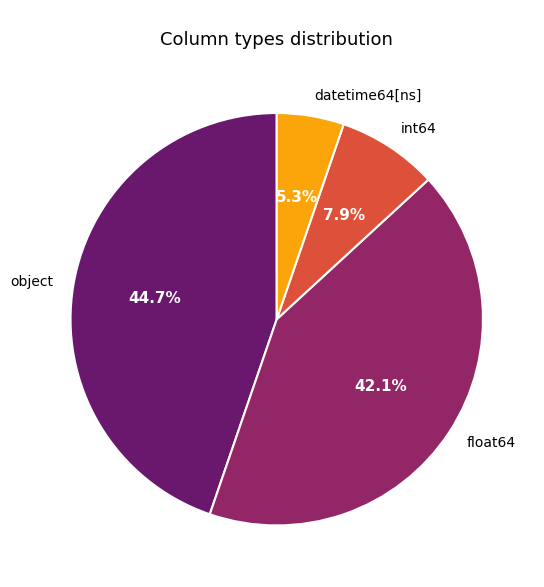

INFO | No empty strings remaining
INFO | NaN ratio OK: 0.03



Number of missing values after preprocessing for each column:
LOCATION                  96.88
DATE_TIME_FIRST_SAMPLE     1.56


In [6]:
logger.info("Post-preprocessing checks")
# Shape after preprocessing
print("Cleaned metadata dataframe shape:", df_meta_clean.shape)

# Number of columns per type
print("\nNumber of columns per type:")
print(df_meta_clean.dtypes.value_counts())

# Pie chart of column types
plot_column_types_pie(
    df_meta_clean, 
    output_dir=FIGURES_DIR,
    filename=f'column_types_distribution_{DATA_TYPE[:3]}.pdf'
)

# Number of missing values after preprocessing
print("\nNumber of missing values after preprocessing for each column:")
missing = df_meta_clean.isnull().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(2).to_string())

empty_strings = (df_meta_clean == '').sum().sum()
check(empty_strings == 0, "No empty strings remaining")

nan_ratio = df_meta_clean.isna().mean().mean()

if nan_ratio > 0.2:
    logger.warning(f"High NaN ratio: {nan_ratio:.2f}")
else:
    logger.info(f"NaN ratio OK: {nan_ratio:.2f}")


## 7. Exploration (post-preprocessing)

Exploratory analysis of the preprocessed metadata, including:

- **Univariate distributions**: histograms and bar plots for numerical and categorical variables
- **Correlation matrix**: identification of linear relationships between numerical variables using Pearson's correlation coefficient:
$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$
- **Station map**: spatial distribution of recording stations relative to the epicenter, colored by peak ground motion
- **Component analysis**: comparison of peak ground motion and signal duration across the three recording components (HNE, HNN, HNZ)

### Constant field identification and filtering

Since the dataset contains recordings from a single seismic event, many columns  are constant across all files (e.g., event coordinates, magnitude, focal mechanism).  Constant fields are identified and exported to a LaTeX table. A reduced dataframe containing only variable columns is then created for subsequent 
analysis and visualization. The peak ground motion column is converted to absolute values to ensure consistent magnitude representation.

In [7]:
# Check which columns have only one unique value
constant_cols = [col for col in df_meta_clean.columns if df_meta_clean[col].nunique() == 1]
logger.info(f"Found {len(constant_cols)} constant columns")

# Create LaTeX table
latex_table = constant_fields_to_latex(
    df_meta_clean, 
    constant_cols, 
    output_path=LATEX_TABLES_DIR / f'constant_fields_after_preprocessing_{DATA_TYPE[:3]}.tex'
)

df_meta_var = df_meta_clean.drop(columns=constant_cols)
df_meta_var = df_meta_var.copy()

# Take absolute value of peak column if present
if PEAK_COLUMN in df_meta_var.columns:
    df_meta_var[PEAK_COLUMN] = df_meta_var[PEAK_COLUMN].abs()
    logger.info(f"Applied abs() to {PEAK_COLUMN}")
else:
    logger.warning(f"{PEAK_COLUMN} not found in variable columns")

# Check if peak column is present
check(len(df_meta_var.columns) > 0, "Variable dataframe is not empty")
check(PEAK_COLUMN in df_meta_var.columns, "Target column present")
logger.info(f"Variable dataframe ready, shape: {df_meta_var.shape}")

INFO | Found 18 constant columns
INFO | Applied abs() to PGA_CM/S^2
INFO | Variable dataframe is not empty
INFO | Target column present
INFO | Variable dataframe ready, shape: (192, 20)


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/acceleration/constant_fields_after_preprocessing_acc.tex


### Numerical distributions

Histograms with kernel density estimates (KDE) for all numerical variables  in the variable-only metadata. Distributions reveal the range and concentration 
of values for quantities such as epicentral distance, peak ground motion, and signal duration.

INFO | Plotting numerical distributions
INFO | Found 12 numerical columns: ['STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE', 'NDATA', 'DURATION_S', 'INSTRUMENTAL_FREQUENCY_HZ', 'PGD_CM', 'TIME_PGD_S', 'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ']


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/numerical_distributions_dis.pdf


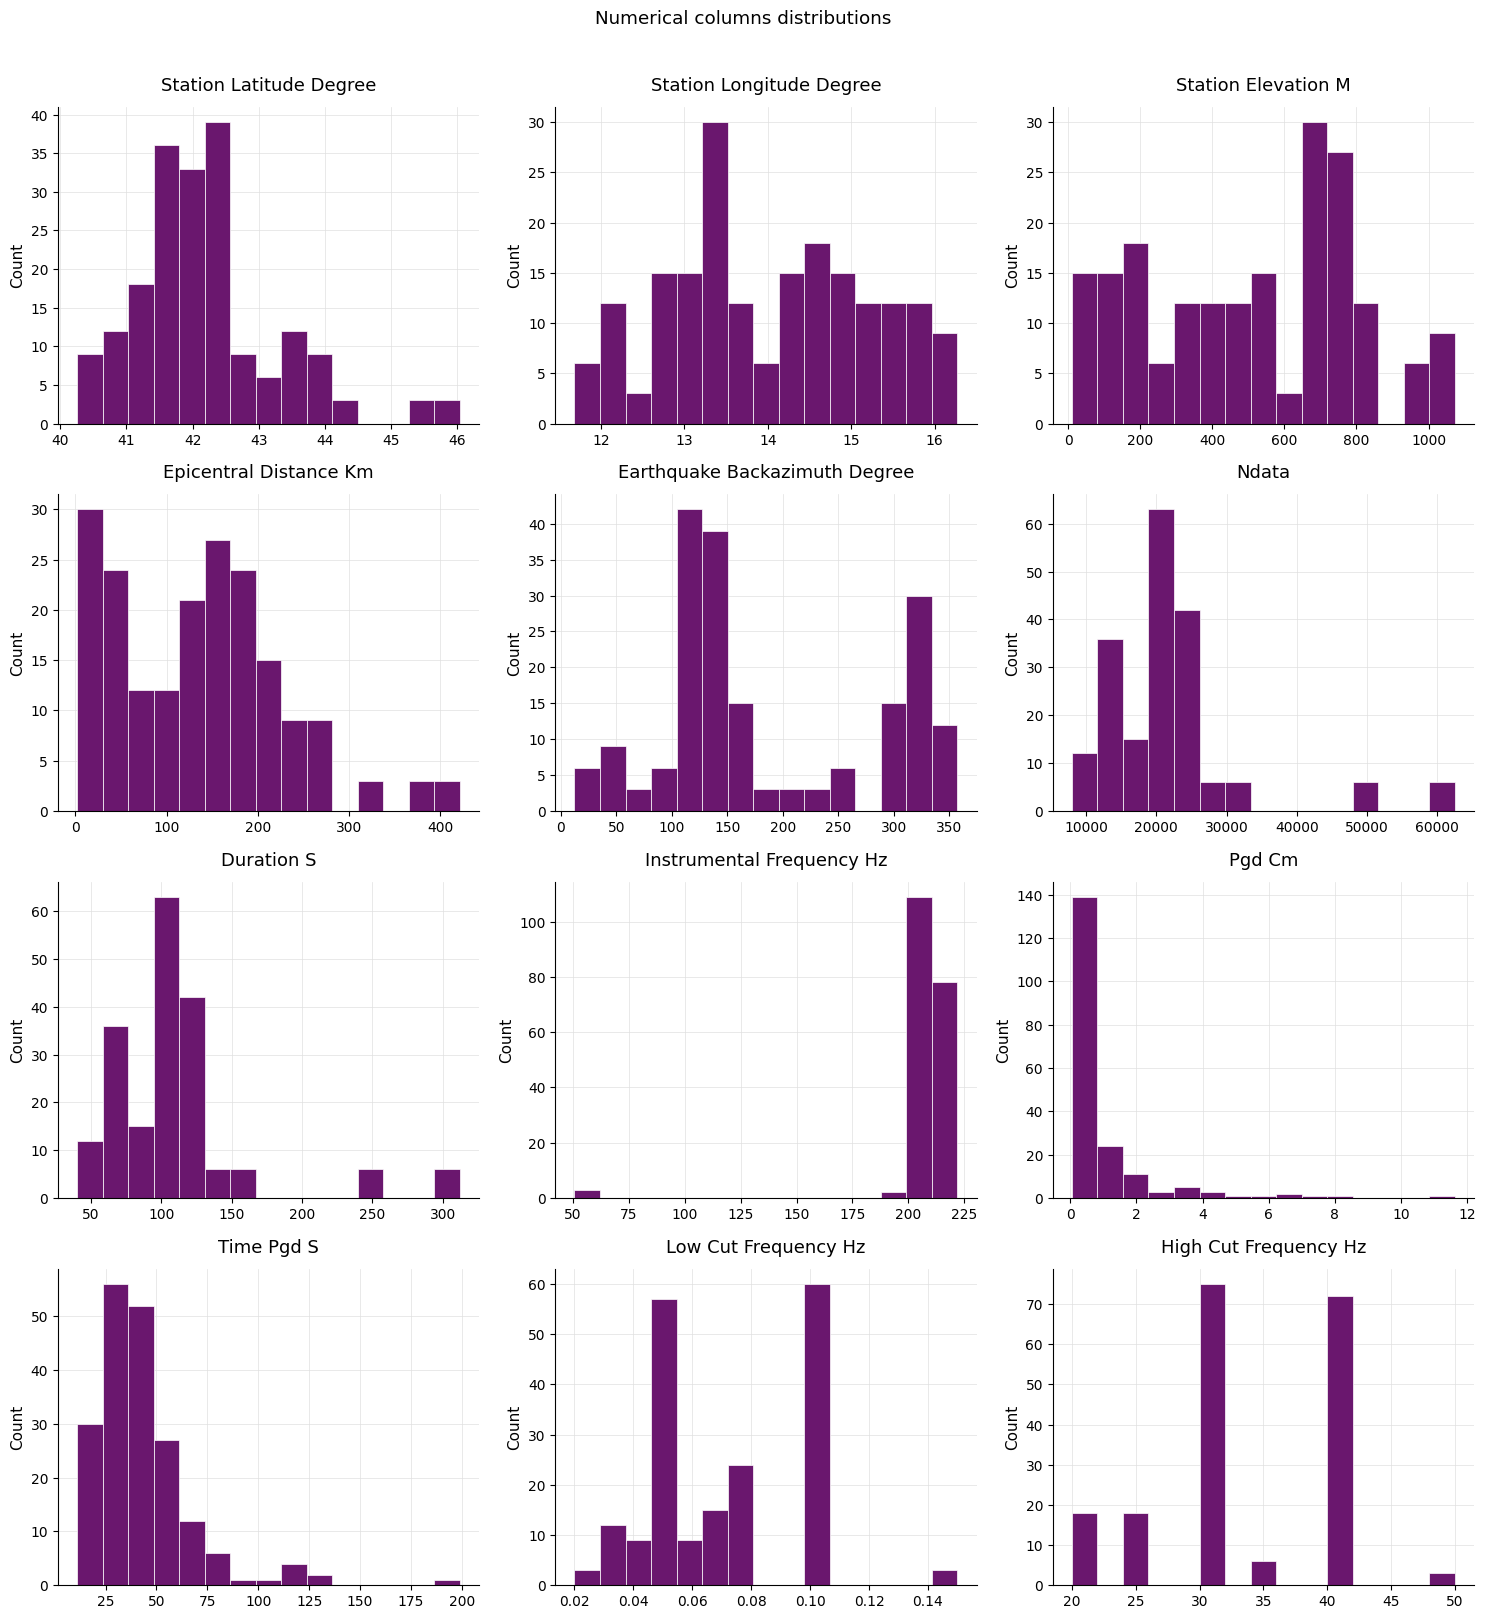

In [20]:
logger.info("Plotting numerical distributions")

# Find numerical columns automatically
num_cols = df_meta_var.select_dtypes(include=['number']).columns.tolist()

# Optionally filter out unwanted columns
exclude_cols = ['file']
num_cols = [col for col in num_cols if col not in exclude_cols]

logger.info(f"Found {len(num_cols)} numerical columns: {num_cols}")

plot_numerical_distributions(
    df_meta_var, 
    num_cols, 
    output_dir=FIGURES_DIR,
    filename=f'numerical_distributions_{DATA_TYPE[:3]}.pdf'
)

### Categorical distributions

Bar charts showing frequency counts for categorical variables in the variable-only metadata. These include station codes, network identifiers, site classification, and instrument types.

INFO | Plotting categorical distributions
INFO | Found 6 categorical columns: ['NETWORK', 'STATION_CODE', 'STATION_NAME', 'SITE_CLASSIFICATION_EC8', 'STREAM', 'INSTRUMENT']


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/acceleration/categorical_distributions_few_acc.pdf


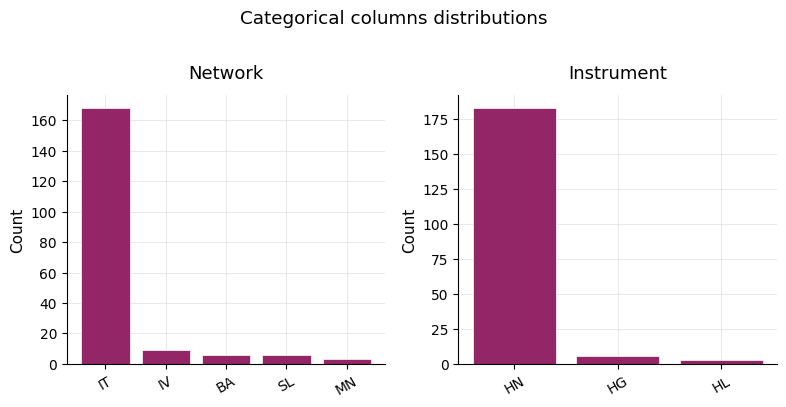

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/acceleration/categorical_distributions_many_acc.pdf


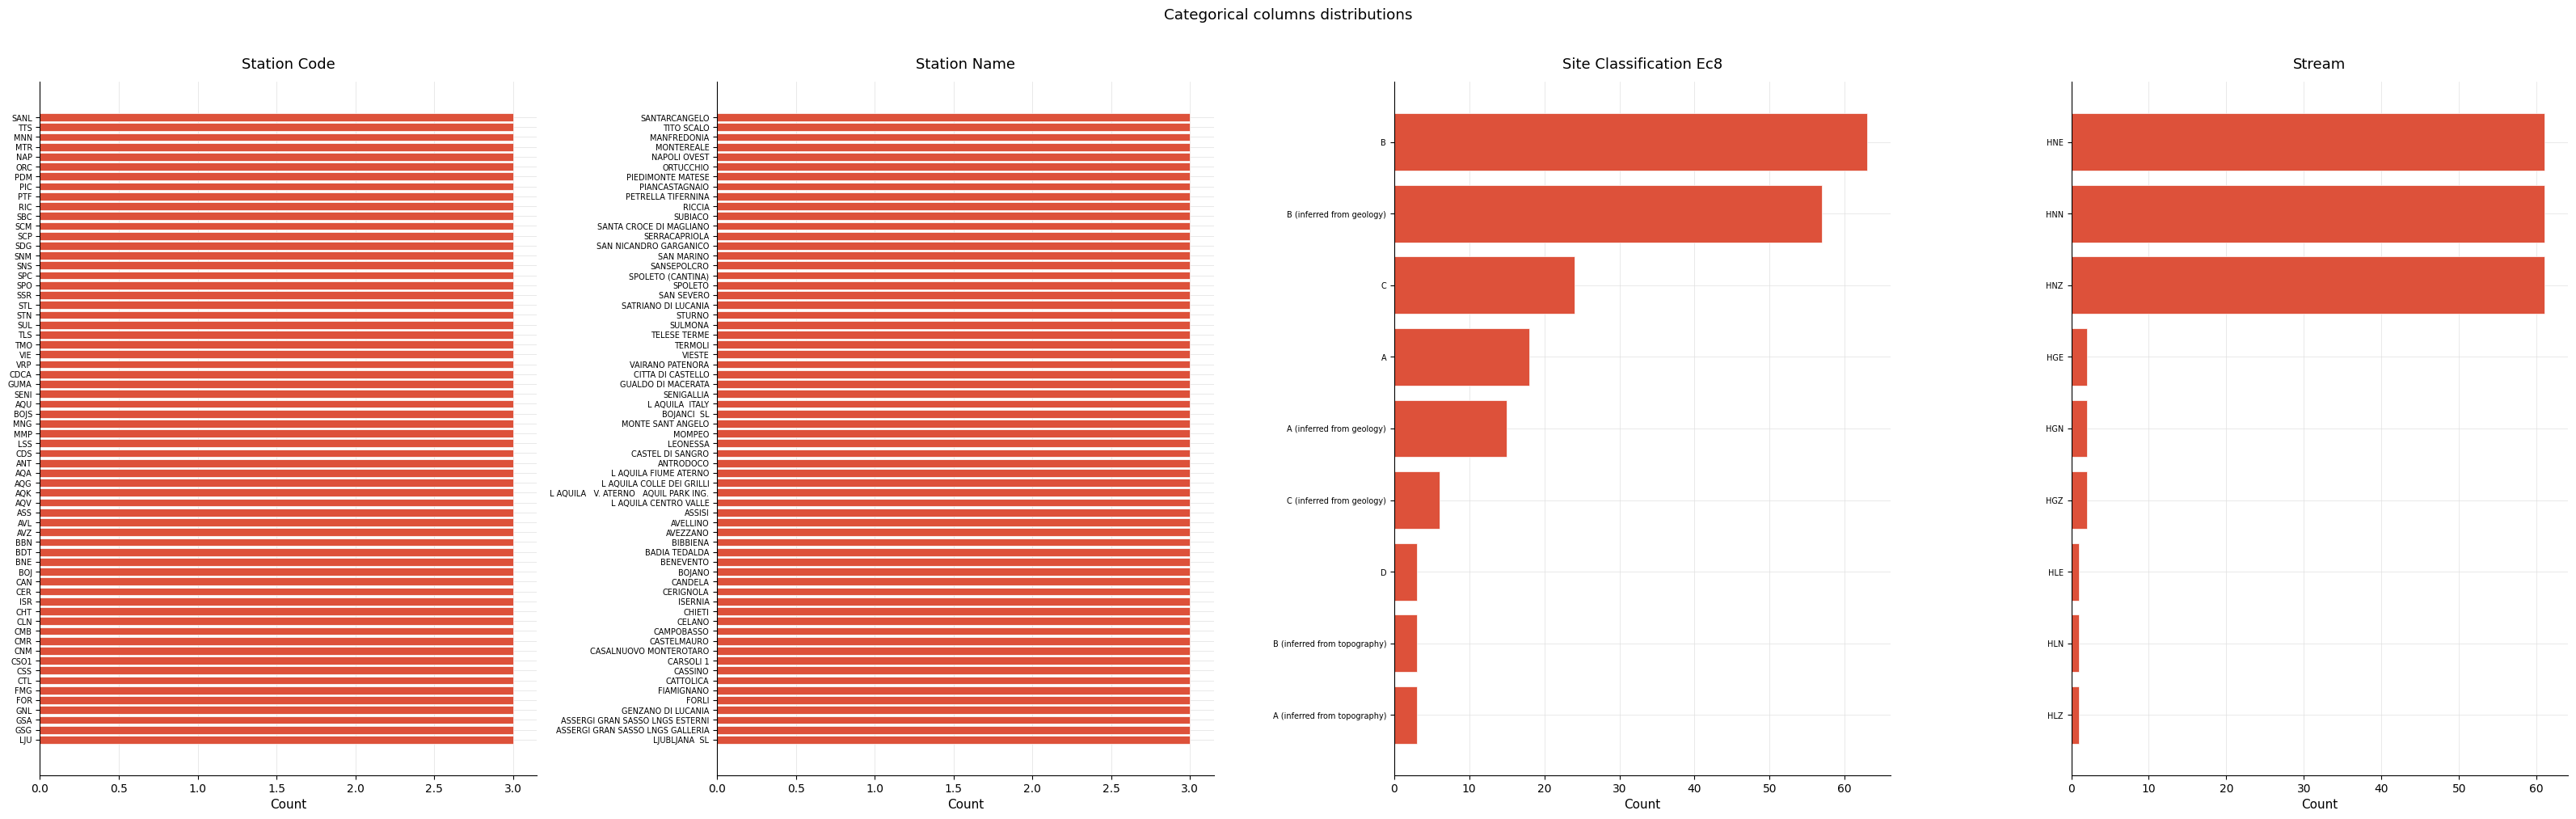

In [8]:
logger.info("Plotting categorical distributions")

# Find categorical columns automatically
cat_cols = df_meta_var.select_dtypes(include=['object']).columns.tolist()

# Optionally filter out unwanted columns
exclude_cols = ['file']
cat_cols = [col for col in cat_cols if col not in exclude_cols]

logger.info(f"Found {len(cat_cols)} categorical columns: {cat_cols}")

plot_categorical_distributions(
    df_meta_var, 
    cat_cols, 
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3]
)

In [9]:
for network in ["MN", "IV"]:
    subset = df_meta_clean[df_meta_clean["NETWORK"] == network]
    print(f"\nNetwork: {network} — {len(subset)} tracce")
    print(subset["STATION_CODE"].value_counts().to_string())


Network: MN — 3 tracce
STATION_CODE
AQU    3

Network: IV — 9 tracce
STATION_CODE
CDCA    3
GUMA    3
SENI    3


### Correlation matrix

Pearson correlation matrix of the numerical variables. Values close to $+1$ or $-1$ indicate strong linear relationships, while values close to $0$ indicate weak or no linear relationship.

INFO | Computing correlation matrix...
INFO | Correlation matrix shape: (12, 12)
INFO | NaN fraction: 0.000


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/correlation_matrix_dis.pdf


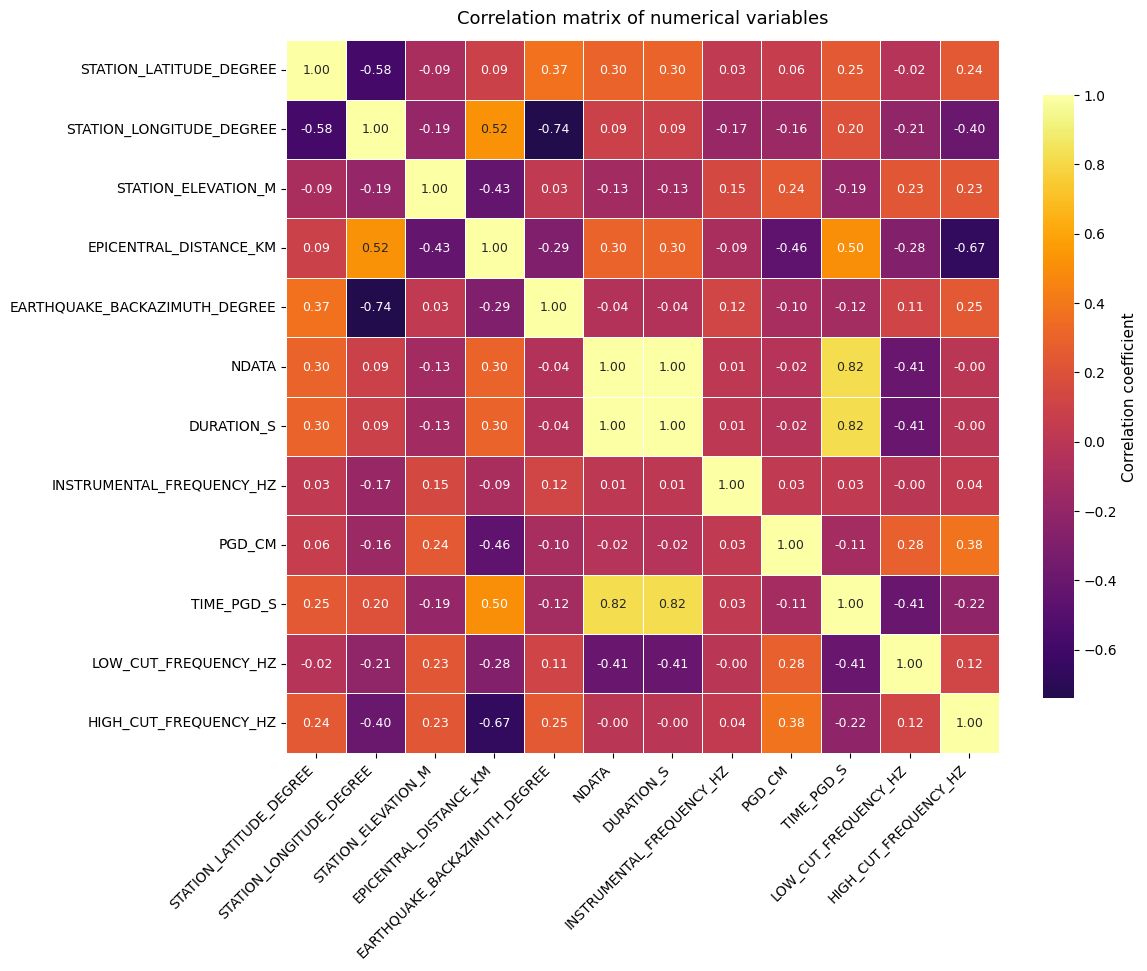

In [22]:
logger.info("Computing correlation matrix...")
corr = df_meta_var.select_dtypes(include=['float64', 'int64']).corr().round(2)
logger.info(f"Correlation matrix shape: {corr.shape}")
logger.info(f"NaN fraction: {corr.isna().mean().mean():.3f}")

plot_correlation_matrix(
    corr,
    title='Correlation matrix of numerical variables',
    output_path=FIGURES_DIR / f'correlation_matrix_{DATA_TYPE[:3]}.pdf'
)

### Station map

Spatial distribution of recording stations. Each station is colored by its peak ground motion value (PGA for acceleration, PGV for velocity, PGD for displacement). The event epicenter is marked with a red star.

INFO | Plotting map with 192 stations


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/station_map_dis.pdf


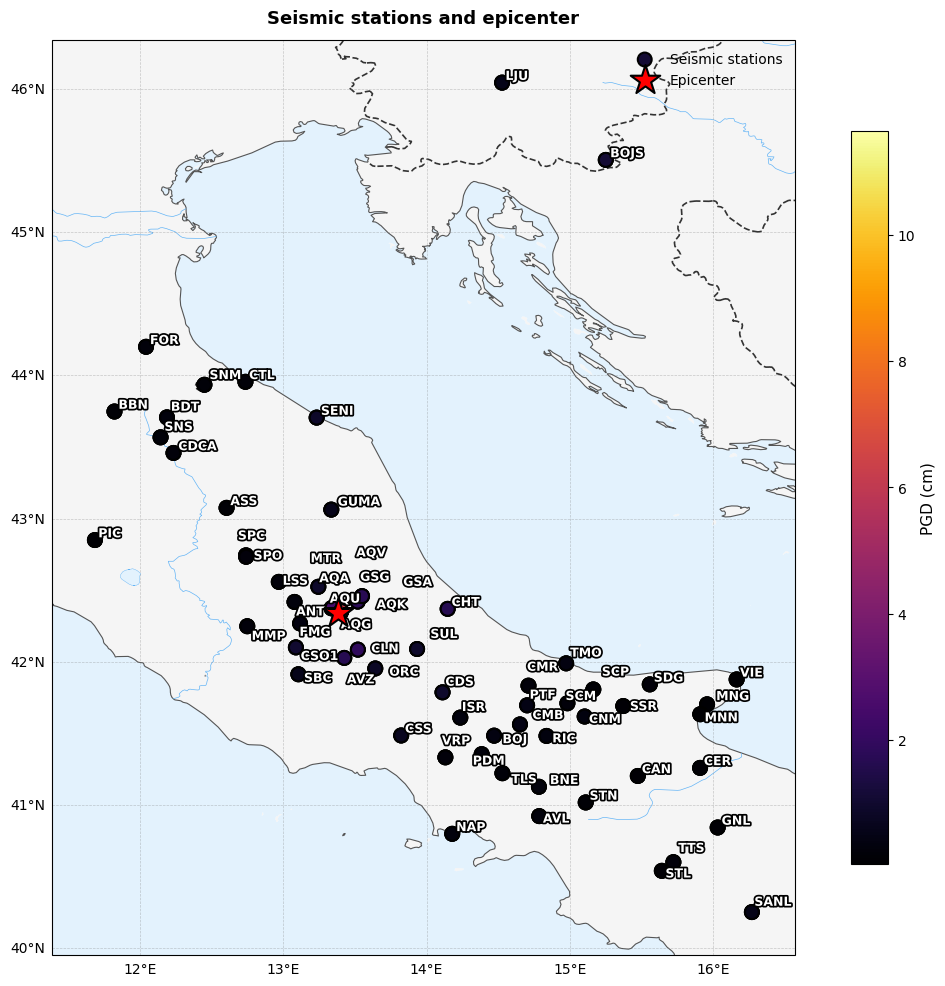

In [23]:
logger.info(f"Plotting map with {len(df_meta_var)} stations")
event_lat = df_meta_clean['EVENT_LATITUDE_DEGREE'].iloc[0]
event_lon = df_meta_clean['EVENT_LONGITUDE_DEGREE'].iloc[0]

plot_station_map(
    df_meta_var, event_lat, event_lon,
    output_path=FIGURES_DIR / f'station_map_{DATA_TYPE[:3]}.pdf',
    peak_column=PEAK_COLUMN
)

### Component analysis

Comparison of peak ground motion and signal duration across the three recording components (E: East-West, N: North-South, Z: vertical). This analysis 
examines whether ground motion characteristics differ systematically by component orientation.

In [24]:
# Map STREAM to component direction
stream_map = {
    'HNZ': 'Z',  # vertical
    'HGZ': 'Z',
    'HLZ': 'Z',
    'HNN': 'N',  # north-south
    'HGN': 'N',
    'HLN': 'N',
    'HN1': 'N',  # ~north, rotated
    'HNE': 'E',  # east-west
    'HGE': 'E',
    'HLE': 'E',
    'HN2': 'E',  # ~east, rotated
}

df_meta_var['COMPONENT'] = df_meta_var['STREAM'].map(stream_map)
print(df_meta_var['COMPONENT'].value_counts())

colors, colors1 = set_plot_style()
components = ['E', 'N', 'Z']
comp_colors = colors[:3] 
missing_comp = df_meta_var['COMPONENT'].isna().sum()

if missing_comp > 0:
    logger.warning(f"{missing_comp} unmapped components")
else:
    logger.info("All components mapped correctly")

INFO | All components mapped correctly


COMPONENT
E    64
N    64
Z    64
Name: count, dtype: int64


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/pga_by_component_dis.pdf


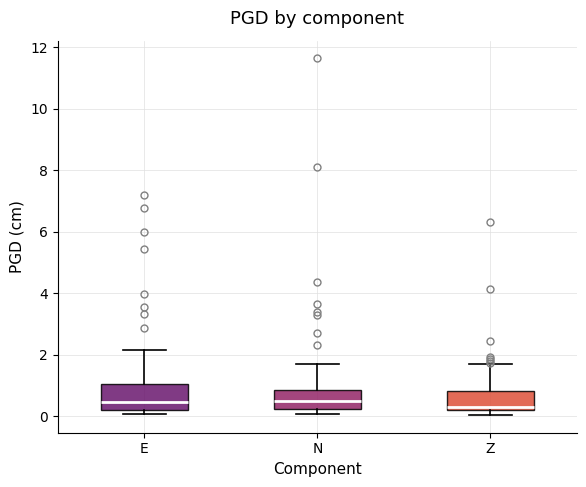

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/pga_vs_distance_by_component_dis.pdf


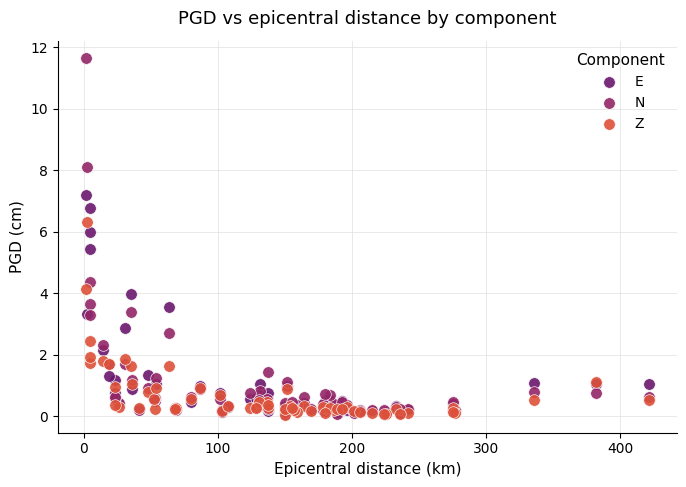

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/duration_by_component_dis.pdf


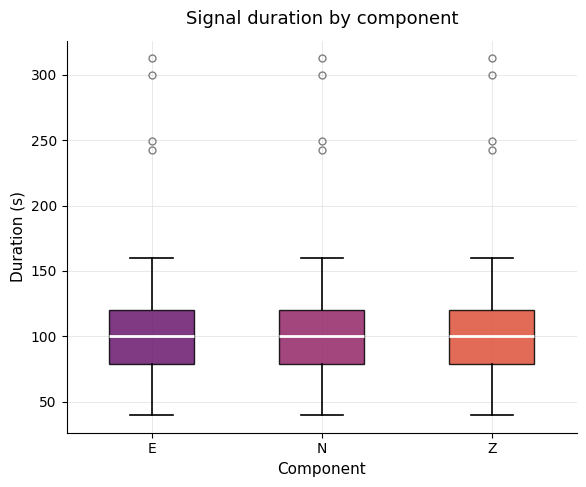

In [25]:
plot_pga_and_duration_by_component(
    df_meta_var, components, comp_colors, 
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3],
    peak_column=PEAK_COLUMN
)

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/correlation_matrix_dis_E.pdf


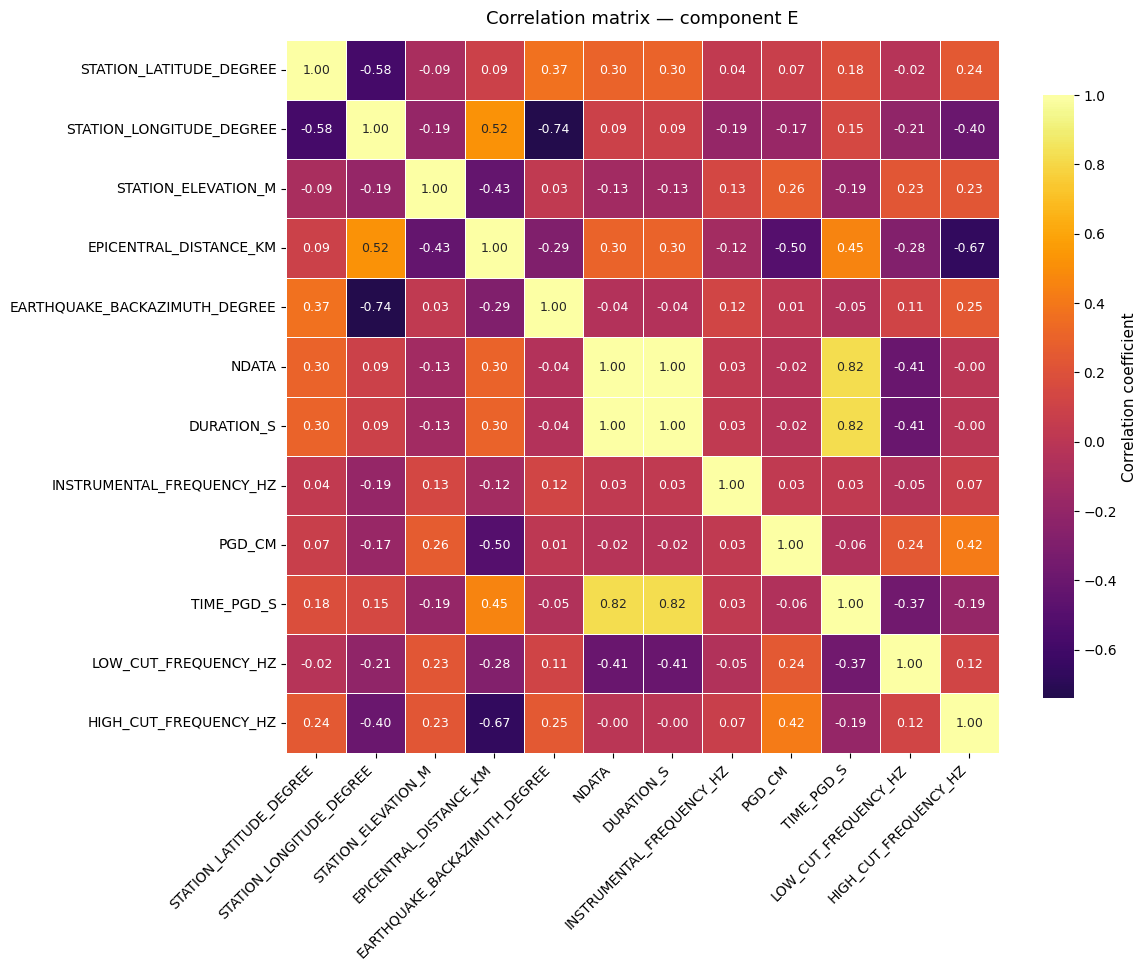

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/correlation_matrix_dis_N.pdf


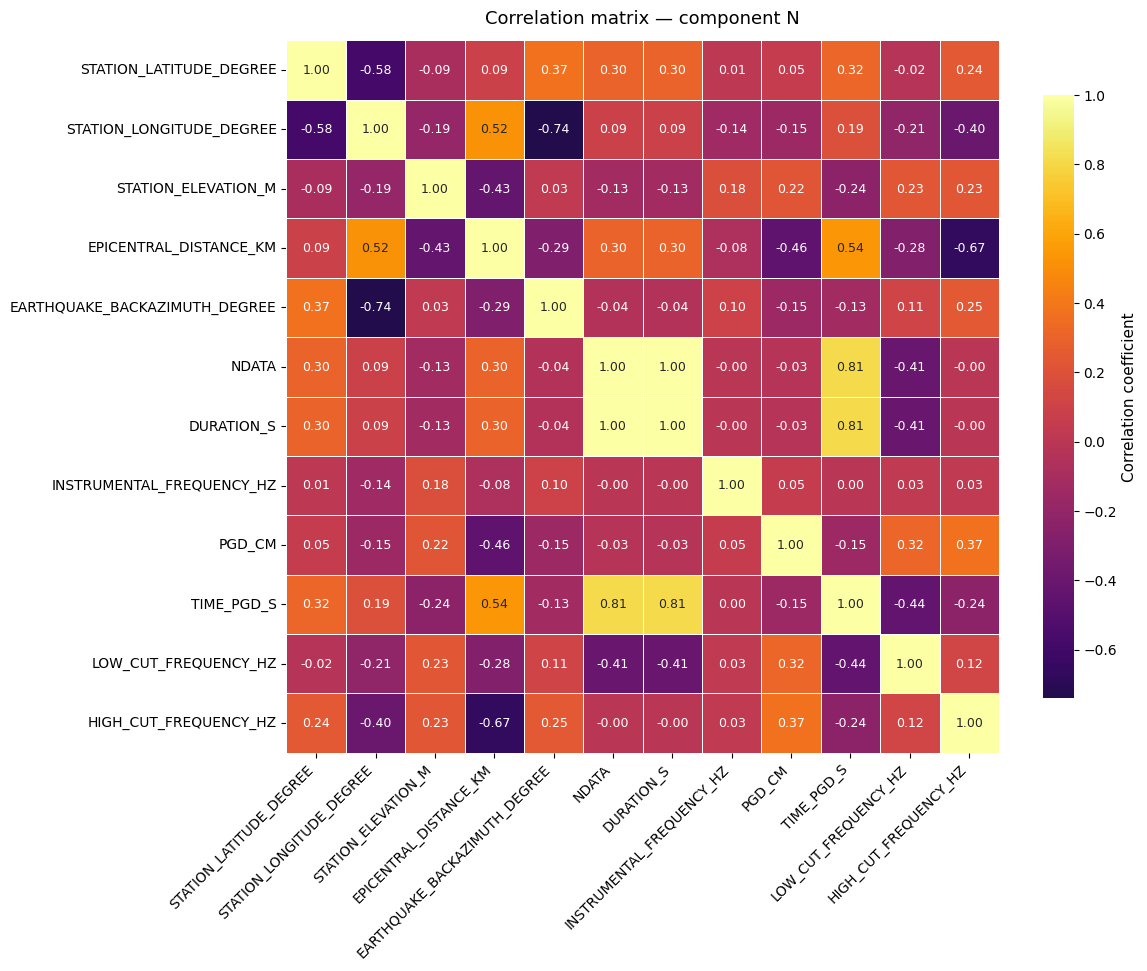

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/correlation_matrix_dis_Z.pdf


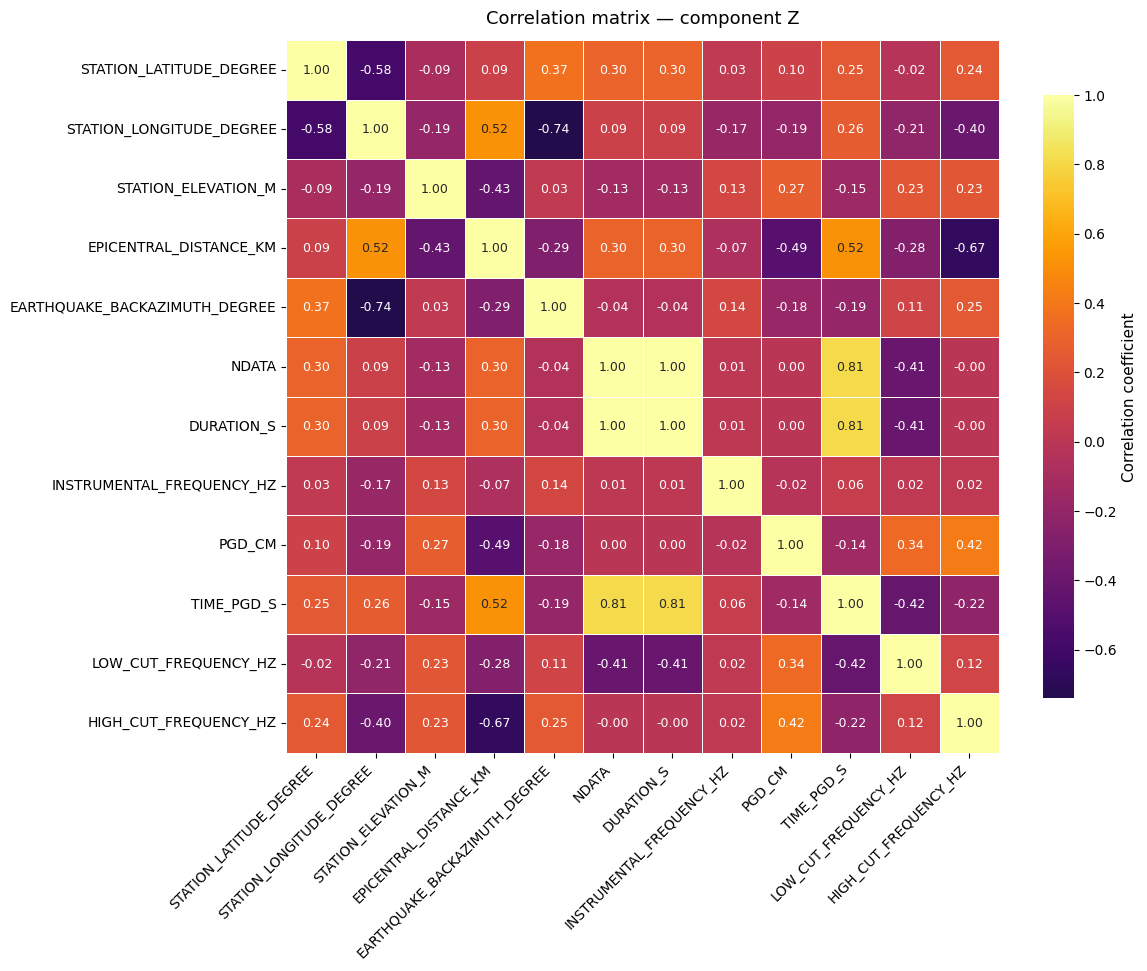

In [26]:
for comp in ['E', 'N', 'Z']:
    subset = df_meta_var[df_meta_var['COMPONENT'] == comp]
    corr_comp = subset.select_dtypes(include=['float64', 'int64']).corr().round(2)
    plot_correlation_matrix(
        corr_comp,
        title=f'Correlation matrix — component {comp}',
        output_path=FIGURES_DIR / f'correlation_matrix_{DATA_TYPE[:3]}_{comp}.pdf'
    )

## 8. Distance-based grouping and correlation analysis

Stations are divided into three groups of approximately equal size based on their epicentral distance using quantile-based binning (`pd.qcut` with $q=3$):
- **Near**: closest third of stations
- **Mid**: middle third of stations
- **Far**: farthest third of stations

Correlation matrices are computed separately for each group to identify distance-dependent relationships. Differences in correlation structure between near and far stations are highlighted to assess the influence of propagation distance on variable interdependencies.

### Station grouping by epicentral distance

In [27]:
logger.info("Creating distance groups...")
# Divide stations into 3 equal groups by epicentral distance
df_stations = df_meta_clean.drop_duplicates('STATION_CODE')[['STATION_CODE', 'EPICENTRAL_DISTANCE_KM']].sort_values('EPICENTRAL_DISTANCE_KM')
df_stations['DISTANCE_GROUP'] = pd.qcut(
    df_stations['EPICENTRAL_DISTANCE_KM'],
    q=3,
    labels=['Near', 'Mid', 'Far']
)
for g in ['Near', 'Mid', 'Far']:
    size = len(df_stations[df_stations['DISTANCE_GROUP'] == g])
    
    if size == 0:
        logger.warning(f"Group {g} is empty")
    else:
        logger.info(f"Group {g}: {size} stations")

display(df_stations.groupby('DISTANCE_GROUP', observed=True)['EPICENTRAL_DISTANCE_KM'].describe())
print("\nStations per group:")
display(df_stations.groupby('DISTANCE_GROUP', observed=True)['STATION_CODE'].apply(list))

# Merge back into df_meta_var
df_meta_var = df_meta_var.merge(
    df_stations[['STATION_CODE', 'DISTANCE_GROUP']],
    on='STATION_CODE',
    how='left'
)

# Setup
groups = ['Near', 'Mid', 'Far']
group_colors = [colors[0], colors[1], colors[2]]

INFO | Creating distance groups...
INFO | Group Near: 21 stations
INFO | Group Mid: 21 stations
INFO | Group Far: 22 stations


,count,mean,std,min,25%,50%,75%,max
DISTANCE_GROUP,,,,,,,,
Near,21.0,32.238095,22.395122,1.8,14.40,30.80,52.800,69.0
Mid,21.0,134.152381,25.514851,80.1,123.80,137.50,154.100,169.4
Far,22.0,238.000000,66.726820,178.5,189.55,219.65,266.875,421.4



Stations per group:


DISTANCE_GROUP
Near    [AQK, AQU, AQV, AQA, AQG, GSA, GSG, MTR, FMG, ...
Mid     [GUMA, CDS, CSS, ASS, ISR, CMR, VRP, PTF, BOJ,...
Far     [BNE, BDT, SSR, NAP, CTL, SDG, SNM, AVL, BBN, ...
Name: STATION_CODE, dtype: object

### Correlation analysis by distance group

Separate correlation matrices are computed for each distance group to investigate whether the linear relationships between variables change with epicentral distance.

INFO | Computing correlation matrices by distance group...


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/correlation_matrix_dis_near.pdf


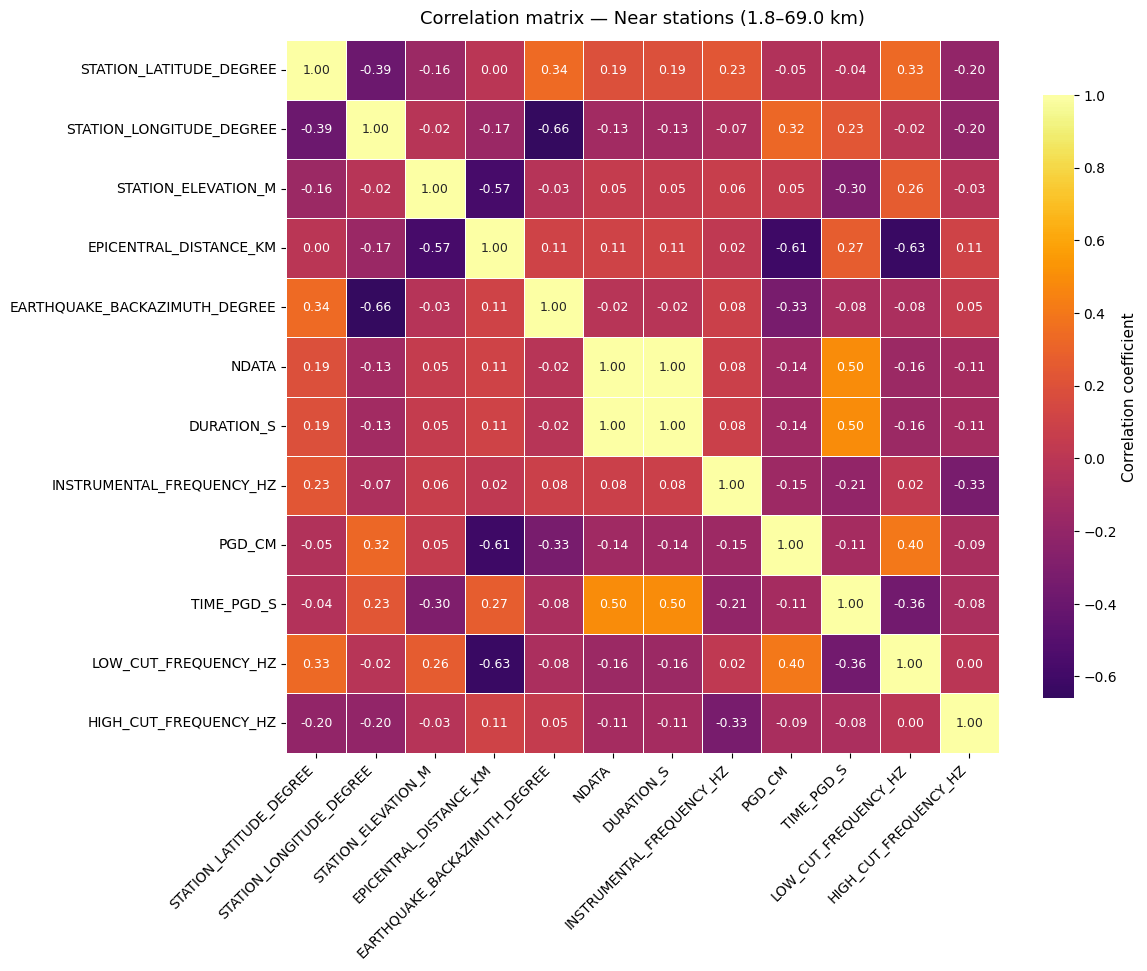

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/correlation_matrix_dis_mid.pdf


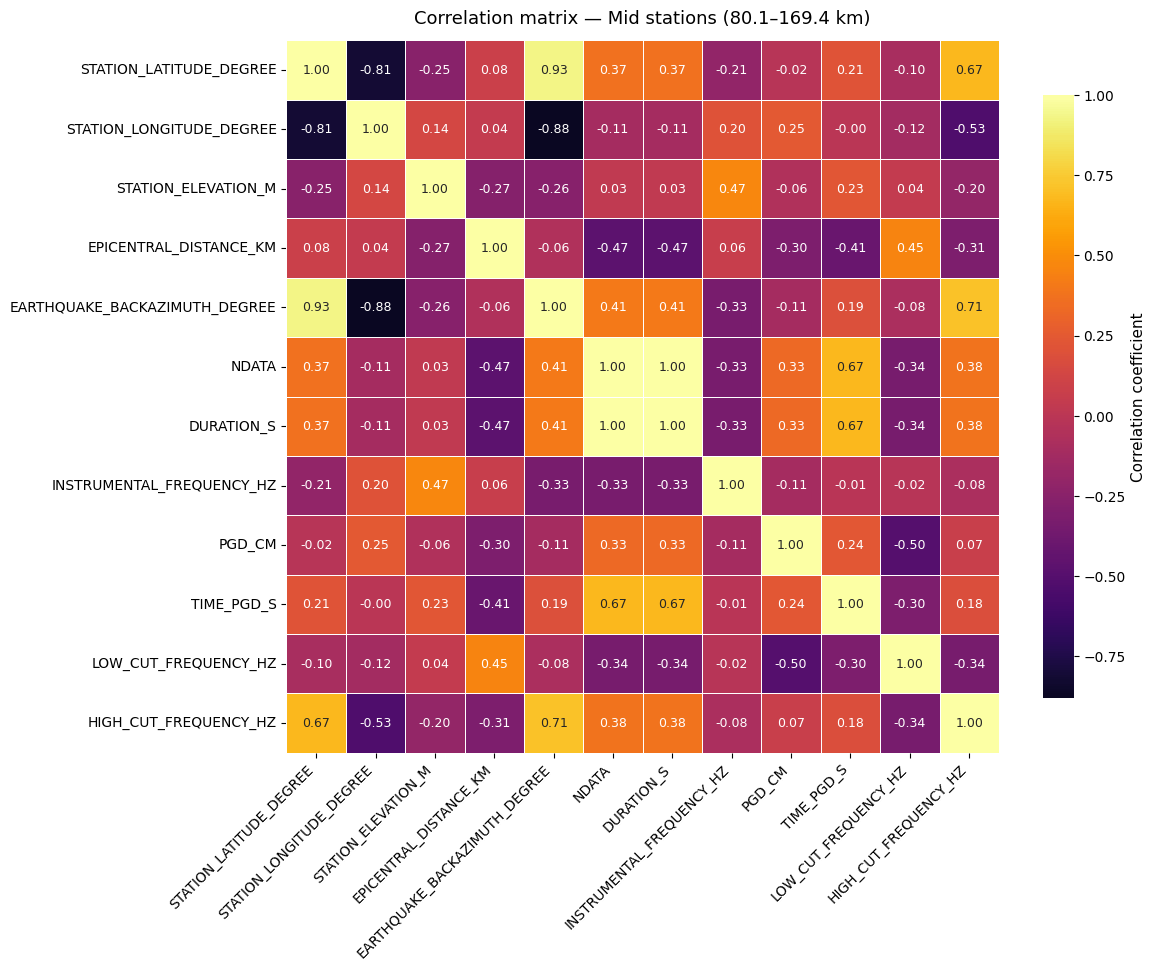

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/correlation_matrix_dis_far.pdf


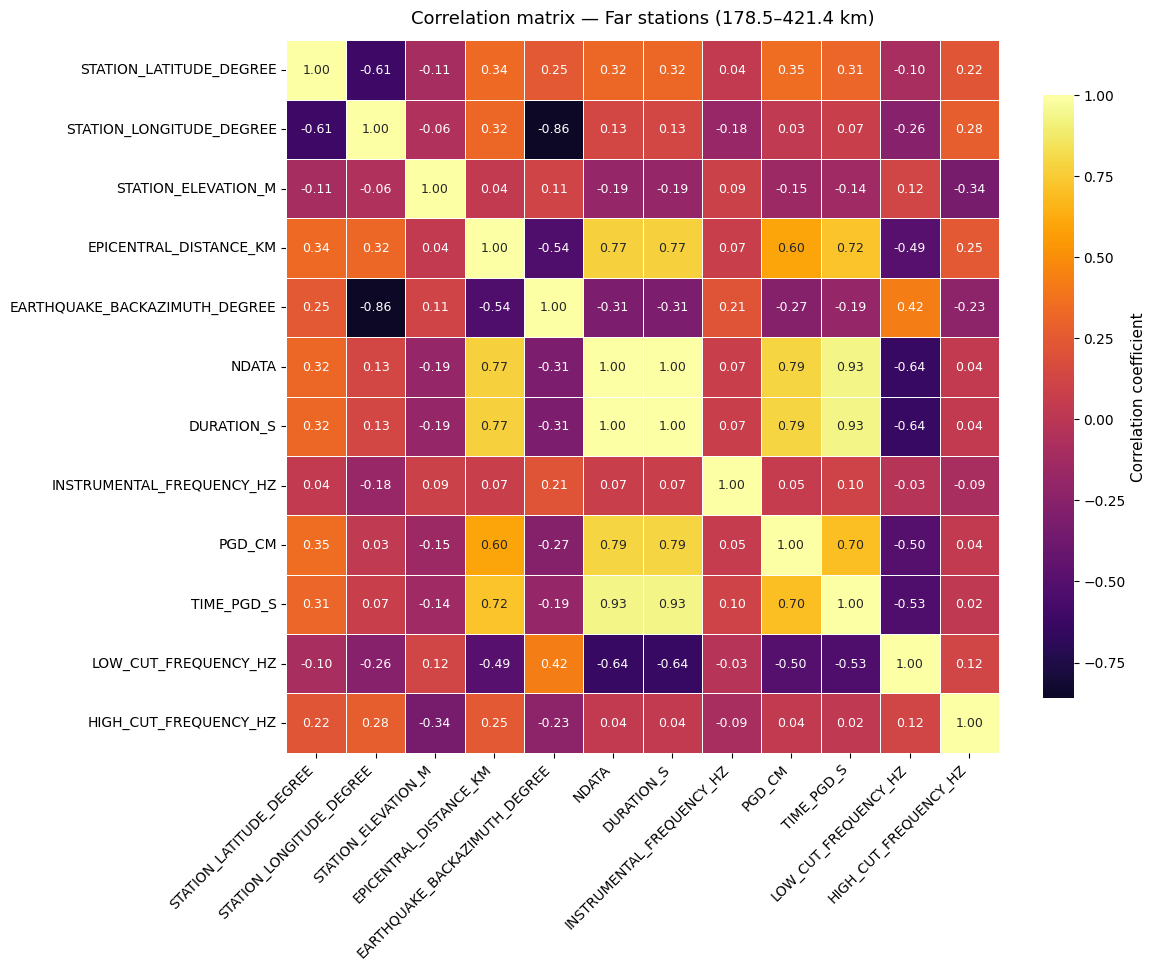

INFO | All distance groups processed


In [28]:
logger.info("Computing correlation matrices by distance group...")
corr_matrices = {}

for group in groups:
    stations_in_group = df_stations[df_stations['DISTANCE_GROUP'] == group]['STATION_CODE'].values
    df_group = df_meta_var[df_meta_var['STATION_CODE'].isin(stations_in_group)]
    dist_min = df_group['EPICENTRAL_DISTANCE_KM'].min()
    dist_max = df_group['EPICENTRAL_DISTANCE_KM'].max()
    
    numeric_df = df_group.select_dtypes(include=['float64', 'int64'])
    numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
    corr_matrices[group] = numeric_df.corr().round(2)
    
    plot_correlation_matrix(
        corr_matrices[group],
        title=f'Correlation matrix — {group} stations ({dist_min}–{dist_max} km)',
        output_path=FIGURES_DIR / f'correlation_matrix_{DATA_TYPE[:3]}_{group.lower()}.pdf'
    )

check(len(corr_matrices) == 3, "All distance groups processed")

### Correlation matrix differences by distance group

The difference between correlation matrices of different distance groups is computed as:

$$\Delta r_{xy} = r_{xy}^{(g_1)} - r_{xy}^{(g_2)}$$

where $r_{xy}^{(g)}$ is the Pearson correlation coefficient between variables $x$ and $y$ for group $g$. Values close to $0$ indicate that the correlation is stable across distance groups, while large values indicate a significant change.

INFO | Common columns across all groups: 12
INFO | Group pairs to compare: [('Near', 'Mid'), ('Near', 'Far'), ('Mid', 'Far')]


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/corr_diff_dis_near_mid.pdf


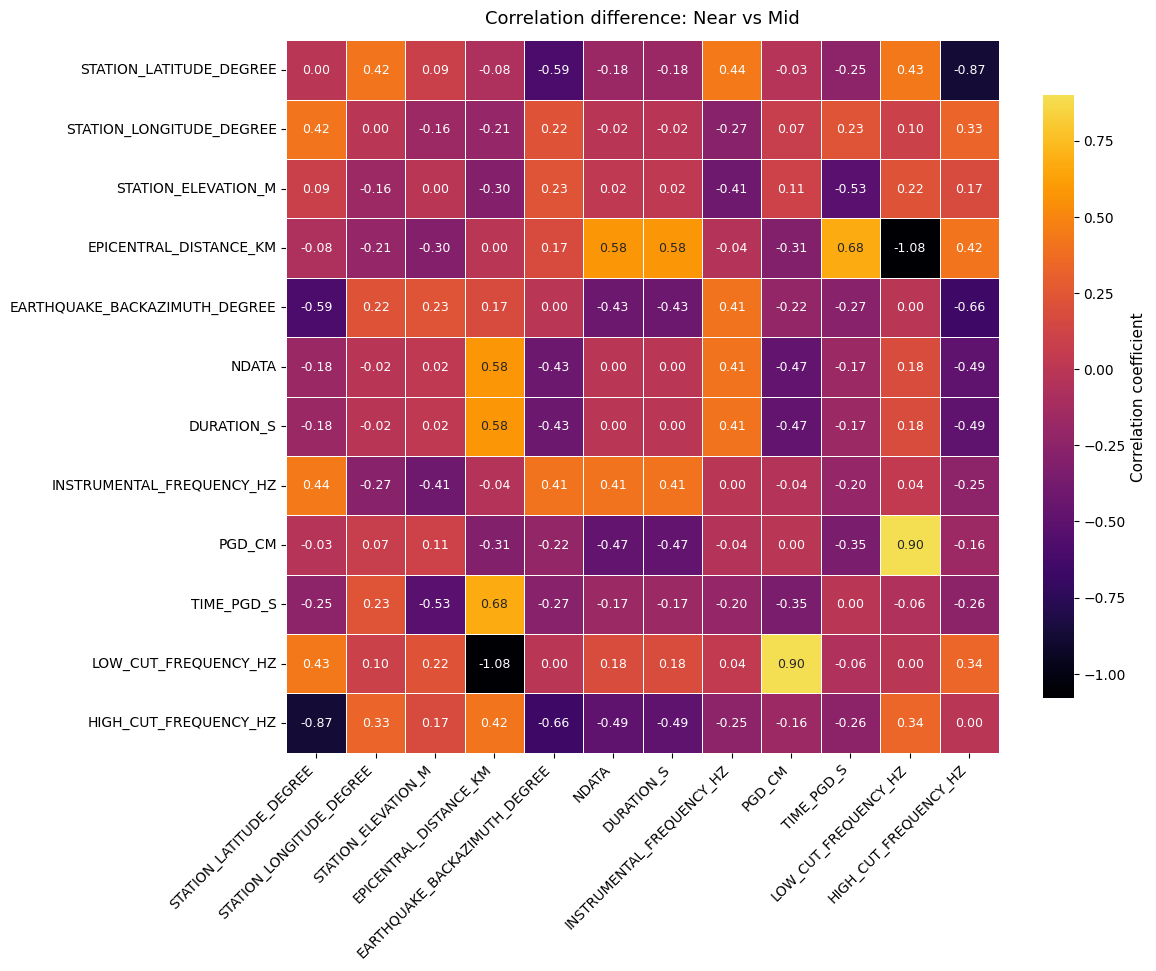

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/corr_diff_dis_near_far.pdf


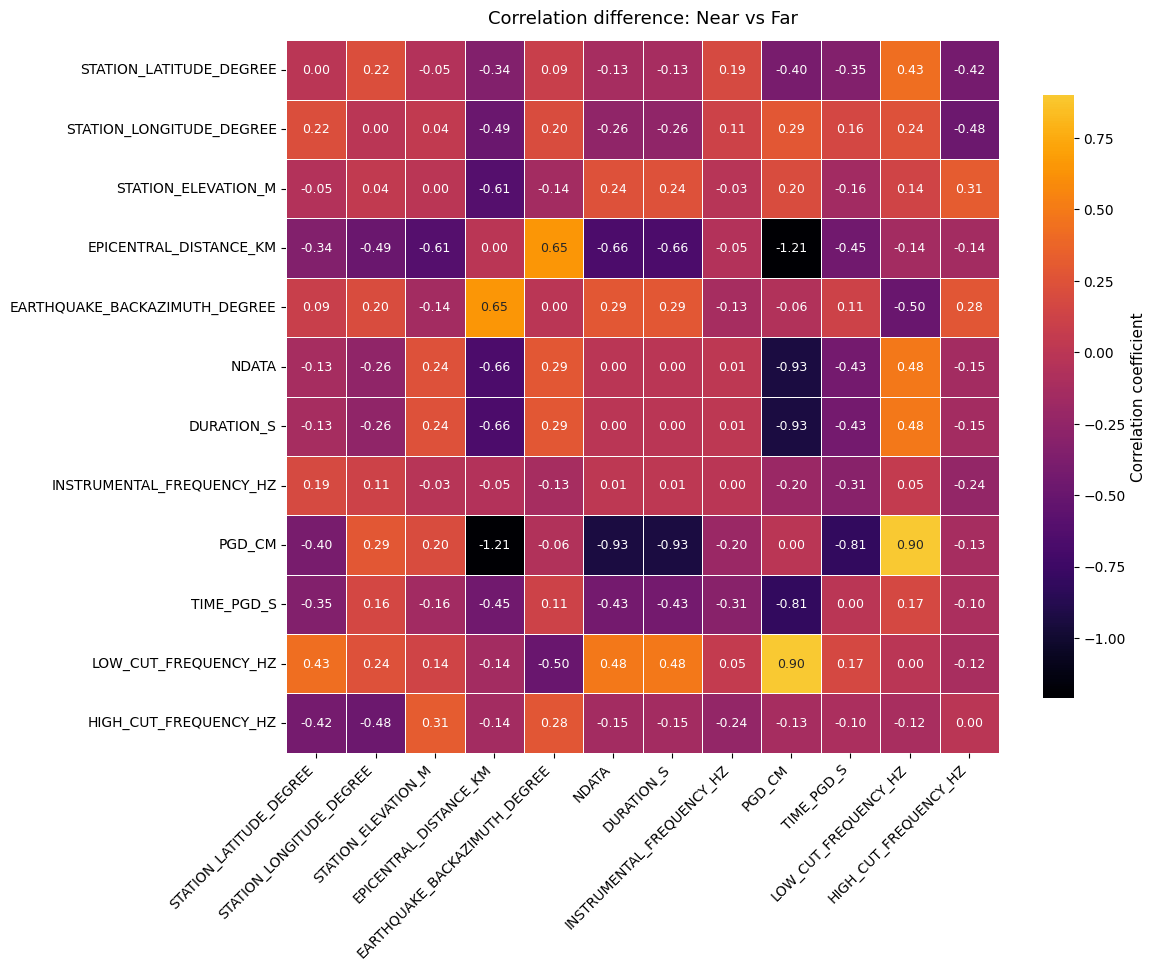

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/corr_diff_dis_mid_far.pdf


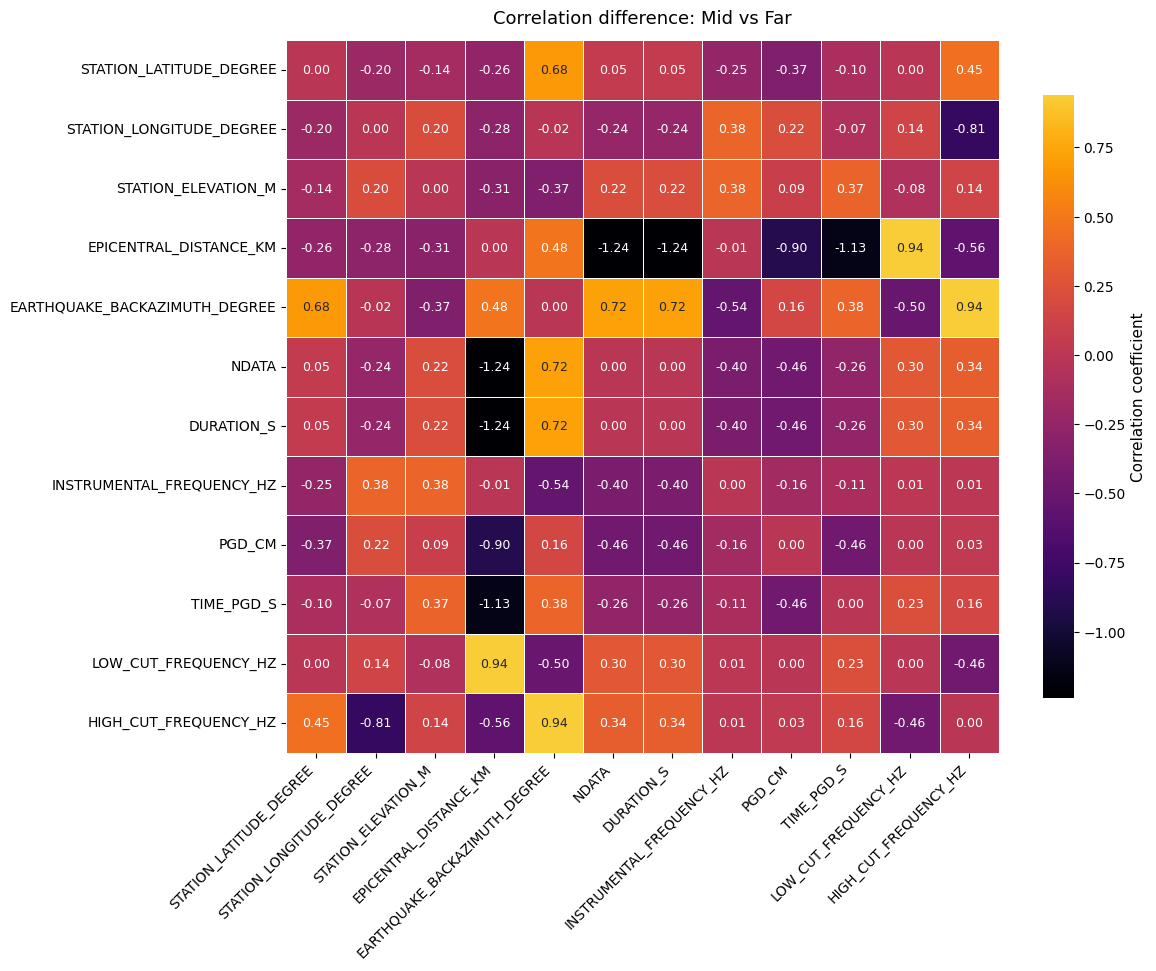

In [29]:
# Find common columns across all groups
common_cols = corr_matrices['Near'].columns
for group in groups:
    common_cols = common_cols.intersection(corr_matrices[group].columns)

group_pairs = list(combinations(groups, 2))
logger.info(f"Common columns across all groups: {len(common_cols)}")
logger.info(f"Group pairs to compare: {group_pairs}")

for g1, g2 in group_pairs:
    diff = (corr_matrices[g1].loc[common_cols, common_cols] -
            corr_matrices[g2].loc[common_cols, common_cols]).round(2)
    plot_correlation_matrix(
        diff,
        title=f'Correlation difference: {g1} vs {g2}',
        output_path=FIGURES_DIR / f'corr_diff_{DATA_TYPE[:3]}_{g1.lower()}_{g2.lower()}.pdf'
    )

### Statistical significance of correlation differences

The statistical significance of the differences between correlation coefficients is assessed using Fisher's z-transformation test. For two correlation coefficients $r_1$ and $r_2$ estimated from samples of size $n_1$ and $n_2$, the test statistic is:

$$z = \frac{z_1 - z_2}{\sqrt{\frac{1}{n_1 - 3} + \frac{1}{n_2 - 3}}}$$

where $z_i = \text{arctanh}(r_i)$ is Fisher's z-transformation. Under the null hypothesis $H_0: r_1 = r_2$, the statistic $z$ follows a standard normal distribution. A significance level of $\alpha = 0.05$ is used.

INFO | Running Fisher z-test on correlation differences...


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/corr_diff_significant_dis_near_mid.pdf


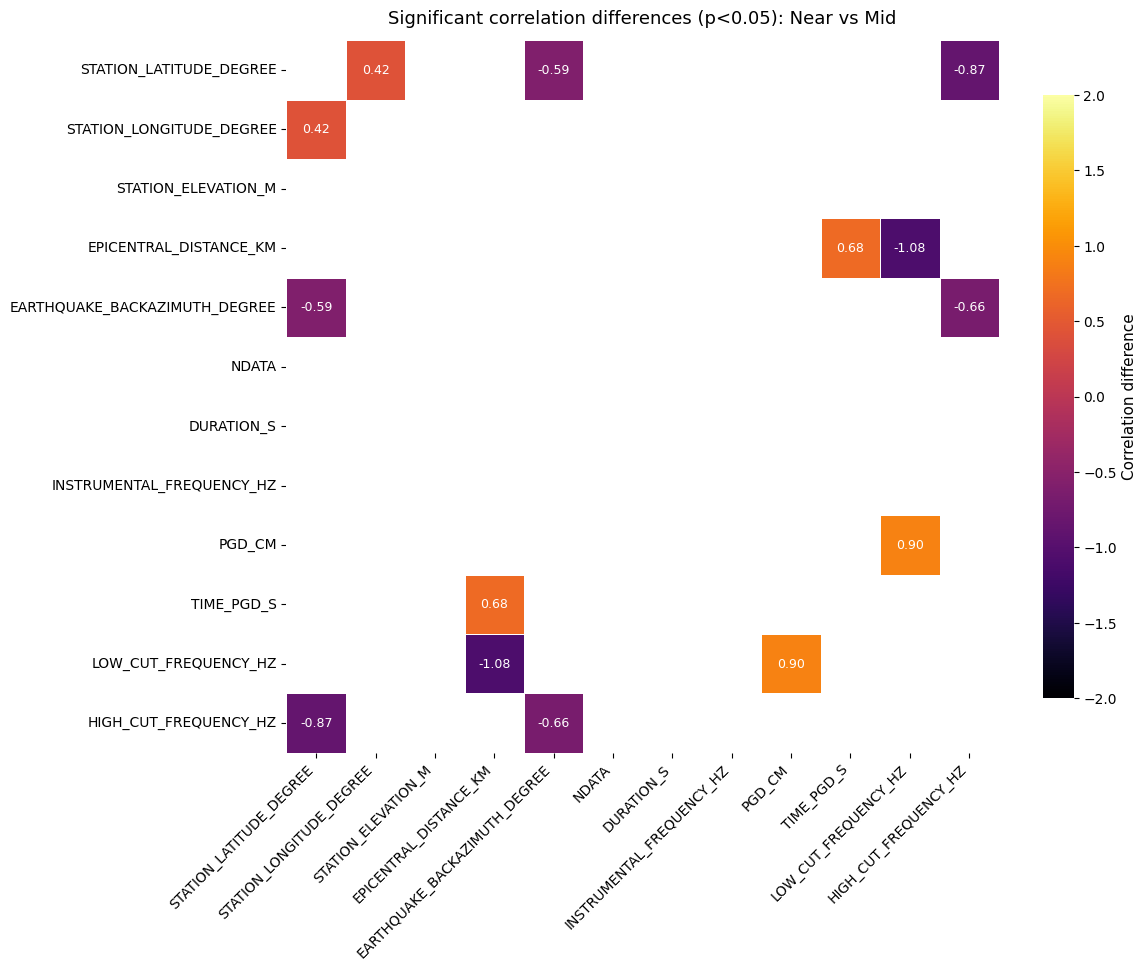

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/corr_diff_significant_dis_near_far.pdf


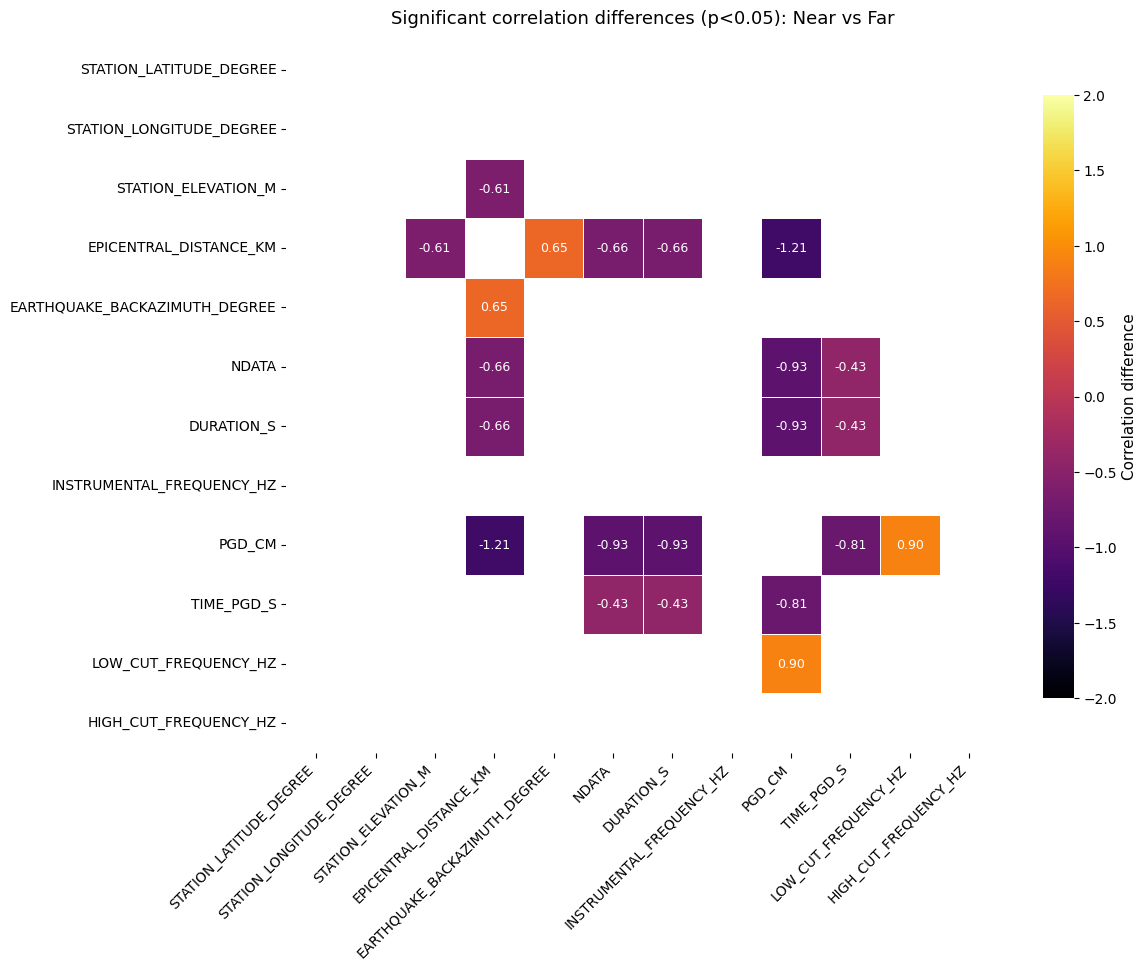

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/corr_diff_significant_dis_mid_far.pdf


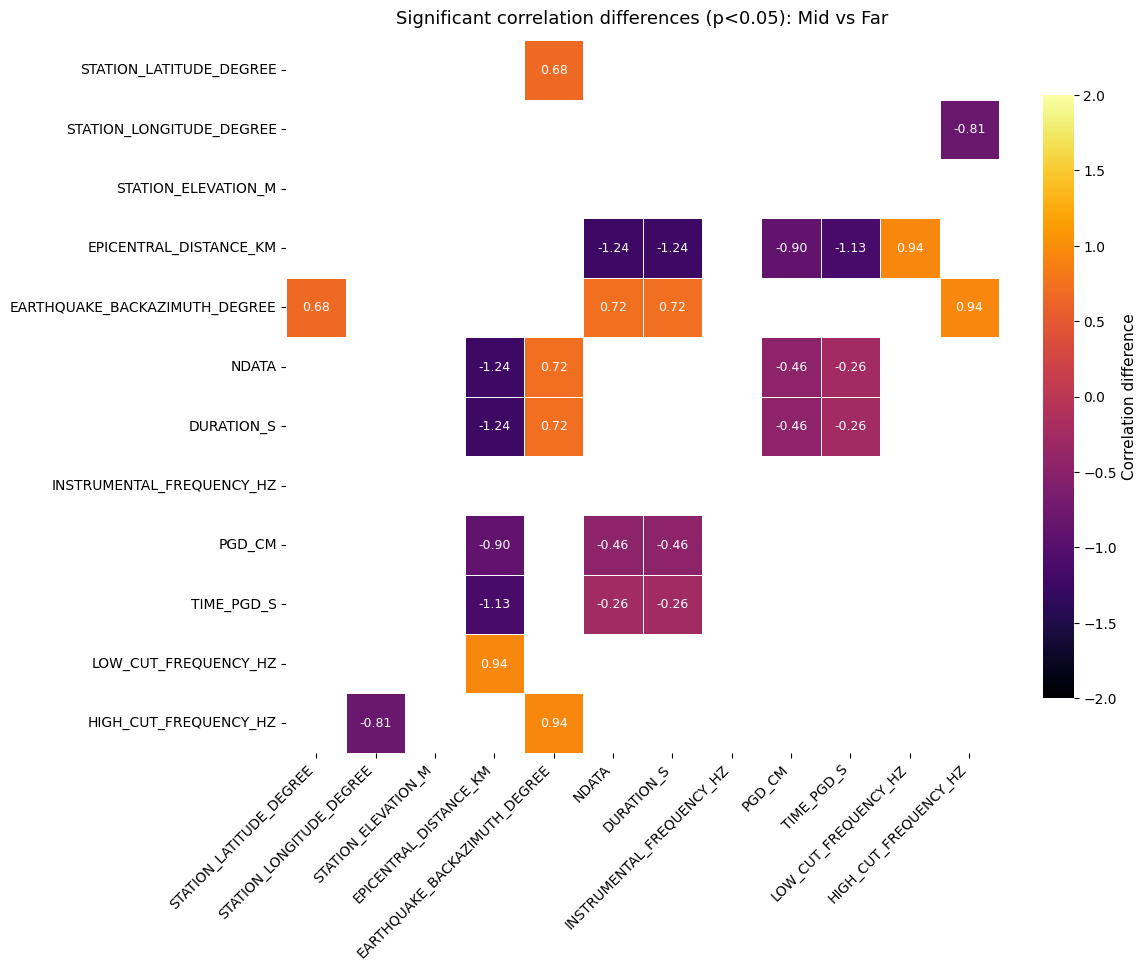

In [30]:
logger.info("Running Fisher z-test on correlation differences...")

def fisher_z_test(r1, r2, n1, n2):
    """Test if two correlation coefficients are significantly different
    using Fisher's z-transformation."""
    # Fisher z-transformation
    z1 = np.arctanh(np.clip(r1, -0.9999, 0.9999))
    z2 = np.arctanh(np.clip(r2, -0.9999, 0.9999))
    # Standard error
    se = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    # z-score and p-value (two-tailed)
    z = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p_value

# Sample sizes per group
n_per_group = {group: len(df_stations[df_stations['DISTANCE_GROUP'] == group]) for group in groups}
alpha = 0.05

for g1, g2 in group_pairs:
    n1, n2 = n_per_group[g1], n_per_group[g2]
    p_matrix = pd.DataFrame(index=common_cols, columns=common_cols, dtype=float)
    
    for col1 in common_cols:
        for col2 in common_cols:
            r1 = corr_matrices[g1].loc[col1, col2]
            r2 = corr_matrices[g2].loc[col1, col2]
            p_matrix.loc[col1, col2] = fisher_z_test(r1, r2, n1, n2)
    
    diff = (corr_matrices[g1].loc[common_cols, common_cols] -
            corr_matrices[g2].loc[common_cols, common_cols]).round(2)
    
    plot_significant_corr_diff(
        diff,
        significant_mask=(p_matrix < alpha),
        title=f'Significant correlation differences (p<{alpha}): {g1} vs {g2}',
        output_path=FIGURES_DIR / f'corr_diff_significant_{DATA_TYPE[:3]}_{g1.lower()}_{g2.lower()}.pdf'
    )

Summary table of statistically significant correlation differences (p < 0.05) between distance groups. For each variable pair showing significant change, the correlation difference and p-value are reported. The table is exported to LaTeX format.

In [31]:
# Build summary table of significant differences
rows = []
for g1, g2 in group_pairs:
    n1 = n_per_group[g1]
    n2 = n_per_group[g2]
    
    for col1 in common_cols:
        for col2 in common_cols:
            if col1 >= col2:  # avoid duplicates (symmetric matrix)
                continue
            r1 = corr_matrices[g1].loc[col1, col2]
            r2 = corr_matrices[g2].loc[col1, col2]
            p = fisher_z_test(r1, r2, n1, n2)
            diff_val = round(r1 - r2, 2)
            
            if p < alpha:
                rows.append({
                    'Comparison': f'{g1} vs {g2}',
                    'Variable 1': col1,
                    'Variable 2': col2,
                    'Corr. diff.': diff_val,
                    'p-value': round(p, 4)
                })

df_significant = pd.DataFrame(rows).sort_values(
    ['Comparison', 'Corr. diff.'],
    ascending=[True, False],
    key=lambda x: x.abs() if x.dtype != 'object' else x
)
check(len(rows) > 0, "Significant differences detected")
logger.info(f"Found {len(rows)} significant differences")

display(df_significant.style
    .format({'Corr. diff.': '{:.2f}', 'p-value': '{:.4f}'})
    .set_caption('Statistically significant correlation differences by distance group (p < 0.05)')
    .background_gradient(subset=['Corr. diff.'], cmap='inferno')
)

output_path = LATEX_TABLES_DIR / f'corr_diff_table_{DATA_TYPE[:3]}.tex'
latex_table = corr_diff_to_latex(df_significant, output_path=output_path)

if output_path.exists():
    logger.info(f"LaTeX table saved: {output_path}")
else:
    logger.error("LaTeX file not created")

INFO | Significant differences detected
INFO | Found 32 significant differences


,Comparison,Variable 1,Variable 2,Corr. diff.,p-value
18,Mid vs Far,EPICENTRAL_DISTANCE_KM,NDATA,-1.24,0.0000
27,Mid vs Far,DURATION_S,EPICENTRAL_DISTANCE_KM,-1.24,0.0000
20,Mid vs Far,EPICENTRAL_DISTANCE_KM,TIME_PGD_S,-1.13,0.0000
21,Mid vs Far,EPICENTRAL_DISTANCE_KM,LOW_CUT_FREQUENCY_HZ,0.94,0.0019
24,Mid vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,HIGH_CUT_FREQUENCY_HZ,0.94,0.0007
19,Mid vs Far,EPICENTRAL_DISTANCE_KM,PGD_CM,-0.90,0.0023
31,Mid vs Far,HIGH_CUT_FREQUENCY_HZ,STATION_LONGITUDE_DEGREE,-0.81,0.0076
23,Mid vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,NDATA,0.72,0.0215
28,Mid vs Far,DURATION_S,EARTHQUAKE_BACKAZIMUTH_DEGREE,0.72,0.0215
22,Mid vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,STATION_LATITUDE_DEGREE,0.68,0.0000


INFO | LaTeX table saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/displacement/corr_diff_table_dis.tex


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/displacement/corr_diff_table_dis.tex


### Peak ground motion correlation with numerical variables by distance group

The Pearson correlation coefficient between peak ground motion and all other numerical variables is computed separately for each distance group and visualized as a grouped bar chart.

INFO | Peak correlation computed for 3 groups


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01a_metadata/displacement/pga_correlation_by_distance_dis.pdf


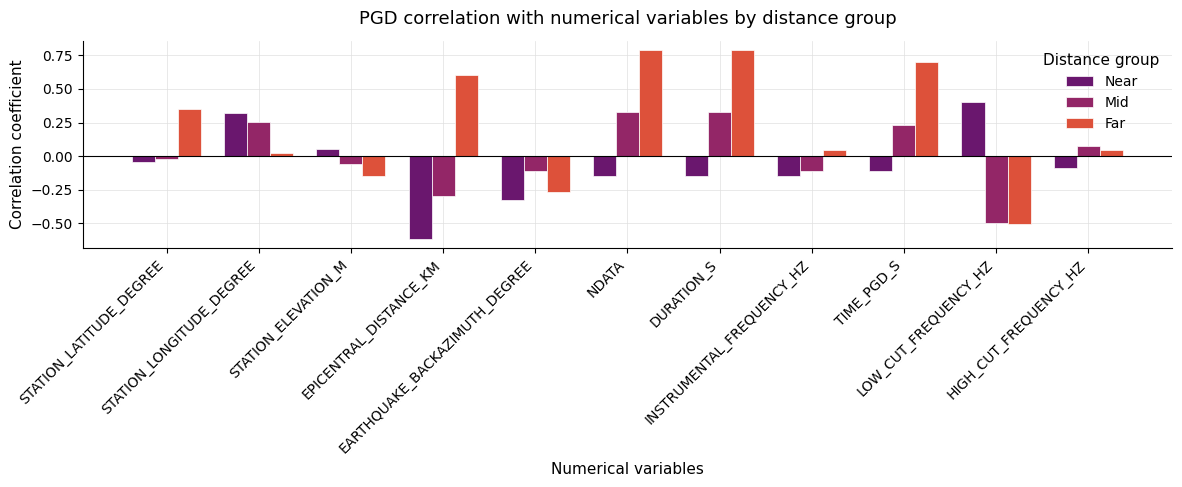

In [32]:
pga_corrs = {}
for group in groups:
    stations_in_group = df_stations[df_stations['DISTANCE_GROUP'] == group]['STATION_CODE'].values
    df_group = df_meta_var[df_meta_var['STATION_CODE'].isin(stations_in_group)]
    numeric_df = df_group.select_dtypes(include=['float64', 'int64'])
    numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
    pga_corrs[group] = numeric_df.corr()[PEAK_COLUMN].drop(PEAK_COLUMN)

df_pga_corr = pd.DataFrame(pga_corrs)
logger.info(f"Peak correlation computed for {len(df_pga_corr.columns)} groups")

plot_pga_correlation_by_group(
    df_pga_corr, groups, group_colors, 
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3],
    peak_column=PEAK_COLUMN
)

## 9. Save preprocessed metadata

The cleaned metadata are saved to parquet format for use in subsequent notebooks.


In [33]:
logger.info("Saving preprocessed metadata...")

# Save full cleaned metadata (all columns)
output_path = DATA_PROCESSED / f'metadata_clean_{DATA_TYPE[:3]}.parquet'
df_meta_clean.to_parquet(output_path, index=False)
logger.info(f"Saved in: {output_path}")
logger.info(f"  Shape: {df_meta_clean.shape}")

# Save variable-only metadata (for exploratory analysis)
output_path_var = DATA_PROCESSED / f'metadata_variable_{DATA_TYPE[:3]}.parquet'
df_meta_var.to_parquet(output_path_var, index=False)
logger.info(f"Saved in: {output_path_var}")
logger.info(f"  Shape: {df_meta_var.shape}")

print("METADATA PREPROCESSING COMPLETED")
print(f"\nOutput files saved to: {DATA_PROCESSED}")
print(f"  - metadata_clean_{DATA_TYPE[:3]}.parquet ({len(df_meta_clean)} rows, {len(df_meta_clean.columns)} columns)")
print(f"  - metadata_variable_{DATA_TYPE[:3]}.parquet ({len(df_meta_var)} rows, {len(df_meta_var.columns)} columns)")

INFO | Saving preprocessed metadata...
INFO | Saved in: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01a_metadata/displacement/metadata_clean_dis.parquet
INFO |   Shape: (192, 38)
INFO | Saved in: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01a_metadata/displacement/metadata_variable_dis.parquet
INFO |   Shape: (192, 22)


METADATA PREPROCESSING COMPLETED

Output files saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01a_metadata/displacement
  - metadata_clean_dis.parquet (192 rows, 38 columns)
  - metadata_variable_dis.parquet (192 rows, 22 columns)
